In [548]:
import zipfile
import os

zip_file_path = '/content/1739525198_datasets.zip'
extract_dir = '/content/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")

'/content/1739525198_datasets.zip' unzipped to '/content/' successfully.


In [549]:
import pandas as pd
df = pd.read_csv(r'/content/marketing_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [550]:
df_dict = pd.read_excel(r'/content/Data Dictionary - Response to marketing campaigns.xlsx')
df_dict.head(n=50)

,Variable,Description
0,ID,Customer's unique identifier
1,Year_Birth,Customer's birth year
2,Education,Customer's education level
3,Marital_Status,Customer's marital status
4,Income,Customer's yearly household income
5,Kidhome,number of small children in customer's househo...
6,Teenhome,no of teenagers in customer's house
7,Dt_Customer,Date of customer's enrollment with the company
8,Recency,number of days since the last purchase
9,MntWines,amount spent on wine in last 2 years


In [551]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [552]:
df['Income'] = pd.to_numeric(
    df[' Income '].str.replace(r'[$,]', '', regex=True),
    errors='coerce'
)

df = df.drop(columns=[' Income '])


In [553]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,1,0,0,0,0,0,1,0,SP,84835.0
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,5,0,0,0,0,1,1,0,CA,57091.0
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,2,0,0,0,0,0,0,0,US,67267.0
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,7,0,0,0,0,0,0,0,AUS,32474.0
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,7,1,0,0,0,0,1,0,SP,21474.0


In [554]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Education:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

Dt_Customer:
Dt_Customer
8/31/12    12
5/12/14    11
9/12/12    11
2/14/13    11
8/20/13    10
           ..
9/19/12     1
6/6/14      1
5/25/13     1
4/9/13      1
9/1/12      1
Name: count, Length: 663, dtype: int64

Country:
Country
SP     1095
SA      337
CA      268
AUS     160
IND     148
GER     120
US      109
ME        3
Name: count, dtype: int64


In [555]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'YOLO': 'Single',
    'Alone': 'Single',
    'Absurd': 'Single'
})


In [556]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,1,0,0,0,0,0,1,0,SP,84835.0
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,5,0,0,0,0,1,1,0,CA,57091.0
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,2,0,0,0,0,0,0,0,US,67267.0
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,7,0,0,0,0,0,0,0,AUS,32474.0
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,7,1,0,0,0,0,1,0,SP,21474.0


In [557]:
df_2 = df.groupby(['Marital_Status','Education'])['Income'].mean().reset_index()

In [558]:
df_2.head(n=25)

,Marital_Status,Education,Income
0,Divorced,2n Cycle,49395.130435
1,Divorced,Basic,9548.000000
2,Divorced,Graduation,54526.042017
3,Divorced,Master,50331.945946
4,Divorced,PhD,53096.615385
5,Married,2n Cycle,46201.100000
6,Married,Basic,21960.500000
7,Married,Graduation,50800.258741
8,Married,Master,53286.028986
9,Married,PhD,58138.031579


In [559]:
# Filter rows with missing income
missing_income = df[df['Income'].isna()]

# Group by Marital_Status and Education (just to see the combinations with missing Income)
missing_income_grouped = missing_income.groupby(['Marital_Status', 'Education']).size().reset_index(name='count')





In [560]:
missing_income_grouped

,Marital_Status,Education,count
0,Married,2n Cycle,1
1,Married,Graduation,4
2,Married,PhD,2
3,Single,2n Cycle,1
4,Single,Graduation,6
5,Single,PhD,2
6,Together,2n Cycle,1
7,Together,Graduation,1
8,Together,Master,4
9,Together,PhD,1


In [561]:
len(df)

2240

In [562]:
df = df.merge(df_2, on=['Marital_Status', 'Education'], how='left', suffixes=('', '_avg'))

In [563]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income,Income_avg
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,0,0,0,0,1,0,SP,84835.0,54526.042017
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,0,0,0,1,1,0,CA,57091.0,51365.633065
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,0,0,0,0,0,US,67267.0,50800.258741
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,0,0,0,0,0,AUS,32474.0,55758.480702
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,1,0,0,0,0,1,0,SP,21474.0,51365.633065


In [564]:
df['Income'] = df['Income'].fillna(df['Income_avg'])

df = df.drop(columns=['Income_avg'])

df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,1,0,0,0,0,0,1,0,SP,84835.0
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,5,0,0,0,0,1,1,0,CA,57091.0
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,2,0,0,0,0,0,0,0,US,67267.0
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,7,0,0,0,0,0,0,0,AUS,32474.0
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,7,1,0,0,0,0,1,0,SP,21474.0


In [565]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [566]:
len(df)

2240

In [567]:
df['Income'].describe()

,Income
count,2240.000000
mean,52248.619720
std,25039.967739
min,1730.000000
25%,35538.750000
50%,51381.500000
75%,68289.750000
max,666666.000000


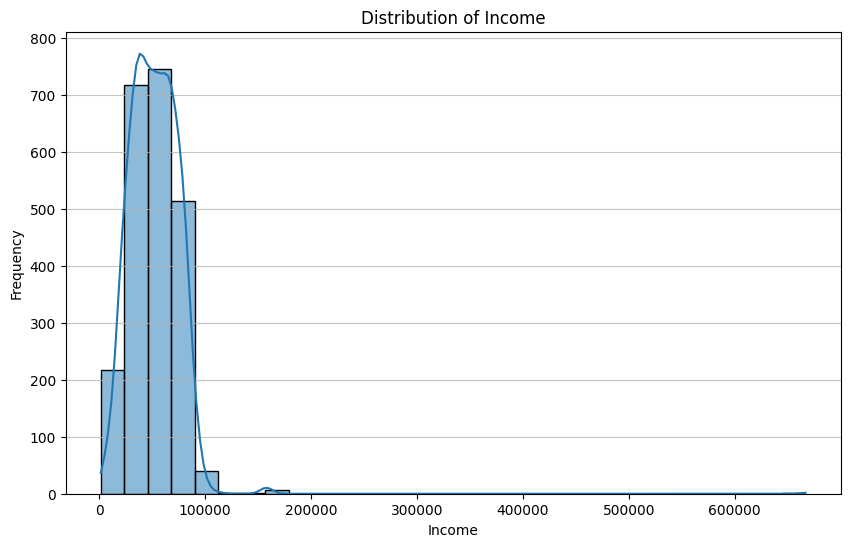

In [568]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], bins=30, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [569]:
percentile_99 = df['Income'].quantile(0.99)
max_income = df['Income'].max()

print(f"99th Percentile of Income: {percentile_99}")
print(f"Maximum Income: {max_income}")

99th Percentile of Income: 94437.68000000001
Maximum Income: 666666.0


In [570]:
df = df[df['Income'] != 666666.0]

In [571]:
print(f"Skewness of Income: {df['Income'].skew()}")

Skewness of Income: 0.3485019948394757


In [572]:
df['Total Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

In [573]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income,Total Purchases
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,0,0,0,0,1,0,SP,84835.0,14
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,0,0,0,1,1,0,CA,57091.0,17
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,0,0,0,0,0,US,67267.0,10
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,0,0,0,0,0,AUS,32474.0,3
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,1,0,0,0,0,1,0,SP,21474.0,6


In [574]:
df.describe()

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Income,Total Purchases
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,...,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.00000,2239.000000
mean,5590.444841,1968.802144,0.443948,0.506476,49.121036,304.067441,26.307727,167.016525,37.538633,27.074587,...,5.316213,0.072800,0.074587,0.072800,0.064314,0.013399,0.149174,0.009379,51974.20374,12.539527
std,3246.372471,11.985494,0.538390,0.544555,28.963662,336.614830,39.781468,225.743829,54.637617,41.286043,...,2.427144,0.259867,0.262782,0.259867,0.245367,0.115001,0.356339,0.096412,21413.16235,7.206400
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1730.00000,0.000000
25%,2827.500000,1959.000000,0.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35533.50000,6.000000
50%,5455.000000,1970.000000,0.000000,0.000000,49.000000,174.000000,8.000000,67.000000,12.000000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51373.00000,12.000000
75%,8423.500000,1977.000000,1.000000,1.000000,74.000000,504.500000,33.000000,232.000000,50.000000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68277.50000,18.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,162397.00000,32.000000


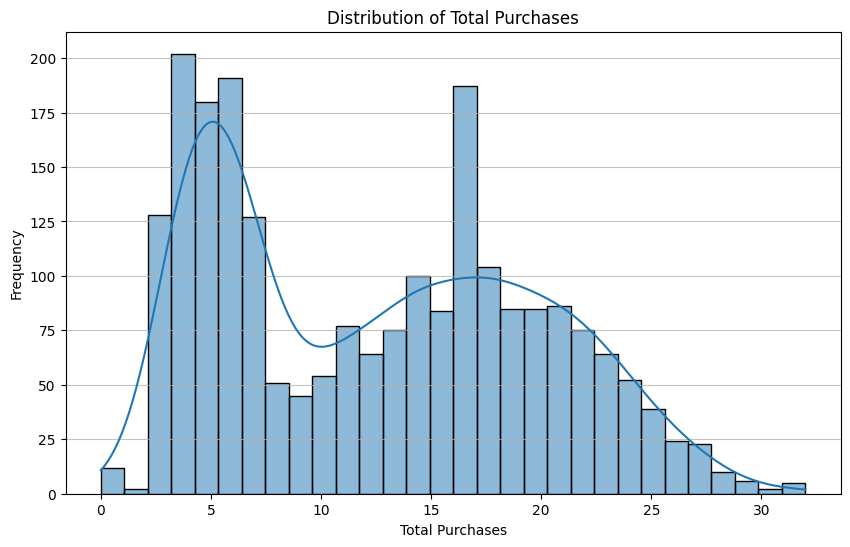

In [575]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Total Purchases'], bins=30, kde=True)
plt.title('Distribution of Total Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

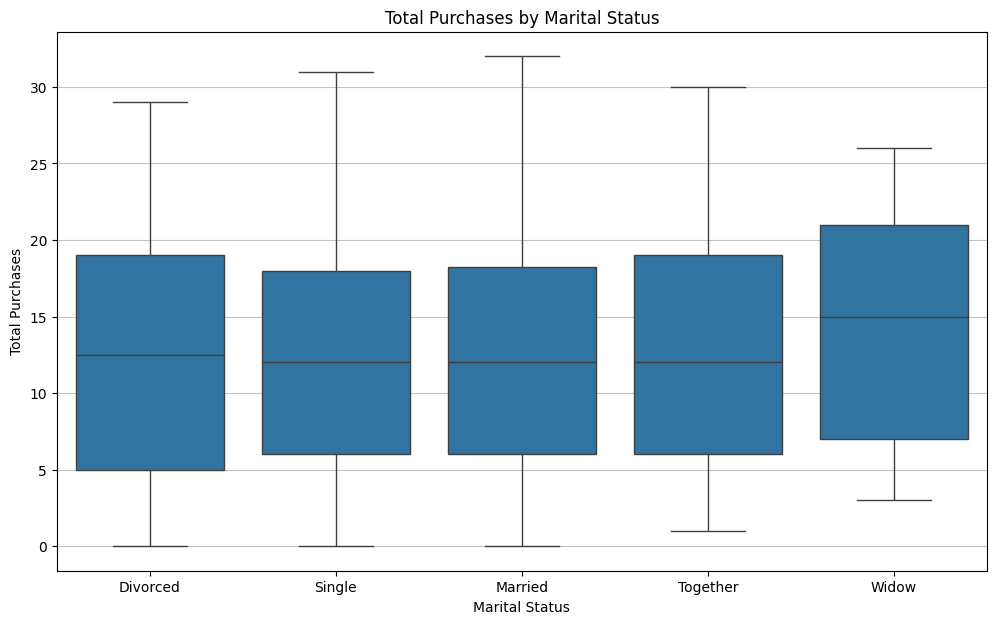

In [576]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='Marital_Status', y='Total Purchases', data=df)
plt.title('Total Purchases by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Purchases')
plt.grid(axis='y', alpha=0.75)
plt.show()

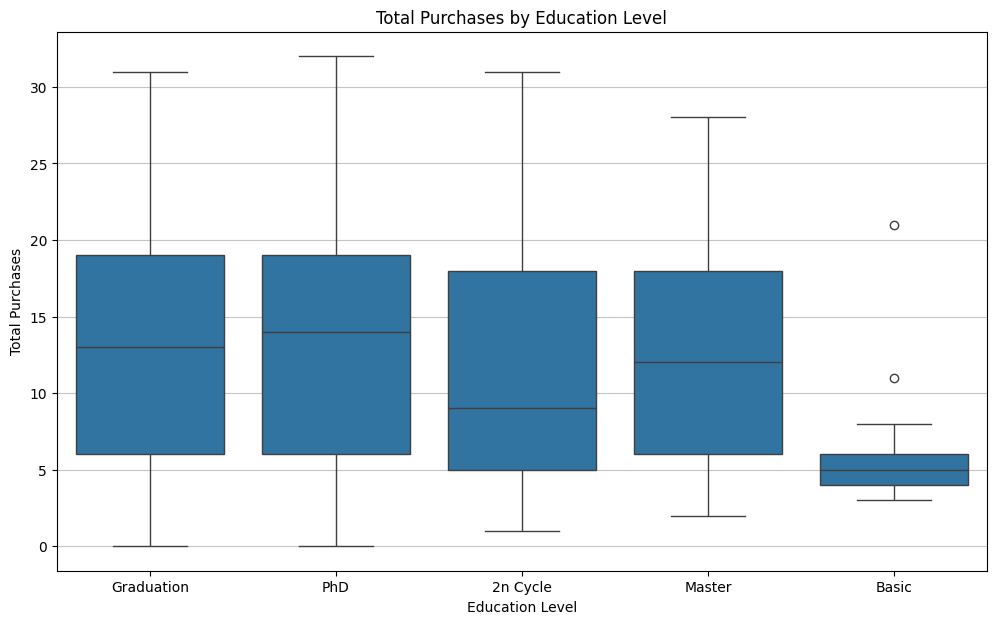

In [577]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='Education', y='Total Purchases', data=df)
plt.title('Total Purchases by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Total Purchases')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [578]:
df['education_encoded'] = pd.Categorical(
    df['Education'],
    categories=['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'],
    ordered=True
).codes


In [579]:
df.groupby(['education_encoded', 'Education']).size()

,,0
education_encoded,Education,
0,Basic,54
1,2n Cycle,203
2,Graduation,1126
3,Master,370
4,PhD,486


In [580]:
# Or if you want to drop the first category to avoid multicollinearity:
df_encoded = pd.get_dummies(df, columns=['Education', 'Marital_Status','Country'], drop_first=True)

In [581]:
df_encoded.head()

,ID,Year_Birth,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US
0,1826,1970,0,0,6/16/14,0,189,104,379,111,...,False,False,False,False,False,False,False,False,True,False
1,1,1961,0,0,6/15/14,0,464,5,64,7,...,True,False,False,True,False,False,False,False,False,False
2,10476,1958,0,1,5/13/14,0,134,11,59,15,...,False,False,False,False,False,False,False,False,False,True
3,1386,1967,1,1,5/11/14,0,10,0,1,0,...,False,True,False,False,False,False,False,False,False,False
4,5371,1989,1,0,4/8/14,0,6,16,24,11,...,True,False,False,False,False,False,False,False,True,False


In [582]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income,Total Purchases,education_encoded
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,0,0,0,1,0,SP,84835.0,14,2
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,0,0,1,1,0,CA,57091.0,17,2
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,0,0,0,0,US,67267.0,10,2
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,0,0,0,0,AUS,32474.0,3,2
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,0,0,0,0,1,0,SP,21474.0,6,2


In [583]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64
MntFruits,int64


In [584]:
import plotly.graph_objects as go

# Heatmap of corelation matrix
df.select_dtypes(include=['int64', 'float64']).drop('ID', axis=1).corr()
# Create a heatmap using plotly
fig = go.Figure(data=go.Heatmap(
               z=df.select_dtypes(include=['int64', 'float64']).drop('ID', axis=1).corr().values,
               x=df.select_dtypes(include=['int64', 'float64']).drop('ID', axis=1).corr().columns,
               y=df.select_dtypes(include=['int64', 'float64']).drop('ID', axis=1).corr().columns,
               colorscale='Blues'))
fig.update_layout(title='Heatmap of Correlation Matrix')
fig.show()

# a.	Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.

In [585]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Income',
       'Total Purchases', 'education_encoded'],
      dtype='object')

In [586]:
# Calculate Age from Year_Birth
df['Age'] = pd.Timestamp('now').year - df['Year_Birth']

In [587]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income,Total Purchases,education_encoded,Age
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,0,0,1,0,SP,84835.0,14,2,55
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,0,1,1,0,CA,57091.0,17,2,64
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,0,0,0,US,67267.0,10,2,67
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,0,0,0,AUS,32474.0,3,2,58
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,0,0,0,1,0,SP,21474.0,6,2,36


In [588]:
df['Retirement_Status'] = df['Age'].apply(lambda x: 'retired' if x > 66 else 'not retired')

In [589]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income,Total Purchases,education_encoded,Age,Retirement_Status
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,0,1,0,SP,84835.0,14,2,55,not retired
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,1,1,0,CA,57091.0,17,2,64,not retired
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,0,0,US,67267.0,10,2,67,retired
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,0,0,AUS,32474.0,3,2,58,not retired
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,0,0,1,0,SP,21474.0,6,2,36,not retired


Qualitatively, this is saying that we need to compare store purchases to web purchases

average retired purchase online >= average retired store purchases

average retired purchase online  < average retired store purchases


In [590]:
retired_df = df[df['Retirement_Status'] == 'retired']

In [591]:
len(retired_df)

519

In [592]:
# Get store and web purchases for older customers
store_purchases = retired_df['NumStorePurchases']
web_purchases = retired_df['NumWebPurchases']


In [593]:
from scipy import stats
# Perform the paired t-test (one-tailed: web < store)
t_stat, p_val = stats.ttest_rel(web_purchases, store_purchases, alternative='less')
print(f"P-value: {p_val}")

P-value: 1.676888886577471e-30


In [594]:
# Interpretation
alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis - older individuals significantly prefer in-store shopping (online < store)")
else:
    print("Fail to reject the null hypothesis - no significant preference for in-store shopping among older individuals")

Reject the null hypothesis - older individuals significantly prefer in-store shopping (online < store)


# b.	Customers with children likely experience time constraints, making online shopping a more convenient option.

In [595]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income,Total Purchases,education_encoded,Age,Retirement_Status
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,0,1,0,SP,84835.0,14,2,55,not retired
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,1,1,0,CA,57091.0,17,2,64,not retired
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,0,0,US,67267.0,10,2,67,retired
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,0,0,AUS,32474.0,3,2,58,not retired
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,0,0,1,0,SP,21474.0,6,2,36,not retired


In [596]:
df['children_count'] = df['Kidhome'] + df['Teenhome']

In [597]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp2,Response,Complain,Country,Income,Total Purchases,education_encoded,Age,Retirement_Status,children_count
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,1,0,SP,84835.0,14,2,55,not retired,0
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,1,1,0,CA,57091.0,17,2,64,not retired,0
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,0,US,67267.0,10,2,67,retired,1
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,0,AUS,32474.0,3,2,58,not retired,2
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,0,1,0,SP,21474.0,6,2,36,not retired,1


In [598]:
import numpy as np

# Create new column 'children_status'
df['children_status'] = np.where(df['children_count'] == 0, 'no children', 'has children')

In [599]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Response,Complain,Country,Income,Total Purchases,education_encoded,Age,Retirement_Status,children_count,children_status
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,1,0,SP,84835.0,14,2,55,not retired,0,no children
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,1,0,CA,57091.0,17,2,64,not retired,0,no children
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,0,US,67267.0,10,2,67,retired,1,has children
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,0,AUS,32474.0,3,2,58,not retired,2,has children
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,1,0,SP,21474.0,6,2,36,not retired,1,has children


In [600]:
df['Online Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases']

In [601]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Complain,Country,Income,Total Purchases,education_encoded,Age,Retirement_Status,children_count,children_status,Online Purchases
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,SP,84835.0,14,2,55,not retired,0,no children,8
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,CA,57091.0,17,2,64,not retired,0,no children,10
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,US,67267.0,10,2,67,retired,1,has children,5
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,AUS,32474.0,3,2,58,not retired,2,has children,1
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,0,SP,21474.0,6,2,36,not retired,1,has children,4


H0: online shopping + catalog  <= instore shopping   --> this means customers either purchased less online or there was no difference
Ha: online shopping + catalog > instore shopping --> this means they purchased significantly more online

In [602]:
customers_with_children = df[df['children_status'] == 'has children']

In [603]:
# Get store and web purchases for older customers
cust_children_store_purchases = customers_with_children['NumStorePurchases']
cust_children_web_purchases = customers_with_children['Online Purchases']

In [604]:
from scipy import stats
# Perform the paired t-test (one-tailed: web < store)
t_stat, p_val = stats.ttest_rel(cust_children_web_purchases, cust_children_store_purchases, alternative='greater')
print(f"P-value: {p_val}")

P-value: 8.387200962412313e-12


In [605]:
# Interpretation
alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis meaning customers with children significantly prefer online shopping (web > store)")
else:
    print("Fail to reject the null hypothesis meaning no significant preference for online shopping among customers with children")

Reject the null hypothesis meaning customers with children significantly prefer online shopping (web > store)


# c.	Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

In [606]:
#group store as group a, group rest as group b.

In [607]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Complain,Country,Income,Total Purchases,education_encoded,Age,Retirement_Status,children_count,children_status,Online Purchases
0,1826,1970,Graduation,Divorced,0,0,6/16/14,0,189,104,...,0,SP,84835.0,14,2,55,not retired,0,no children,8
1,1,1961,Graduation,Single,0,0,6/15/14,0,464,5,...,0,CA,57091.0,17,2,64,not retired,0,no children,10
2,10476,1958,Graduation,Married,0,1,5/13/14,0,134,11,...,0,US,67267.0,10,2,67,retired,1,has children,5
3,1386,1967,Graduation,Together,1,1,5/11/14,0,10,0,...,0,AUS,32474.0,3,2,58,not retired,2,has children,1
4,5371,1989,Graduation,Single,1,0,4/8/14,0,6,16,...,0,SP,21474.0,6,2,36,not retired,1,has children,4


In [608]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64
MntFruits,int64


In [609]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df.dtypes

/tmp/ipython-input-3219777381.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64
MntFruits,int64


In [610]:
df['Year_Customer'] = df['Dt_Customer'].dt.year

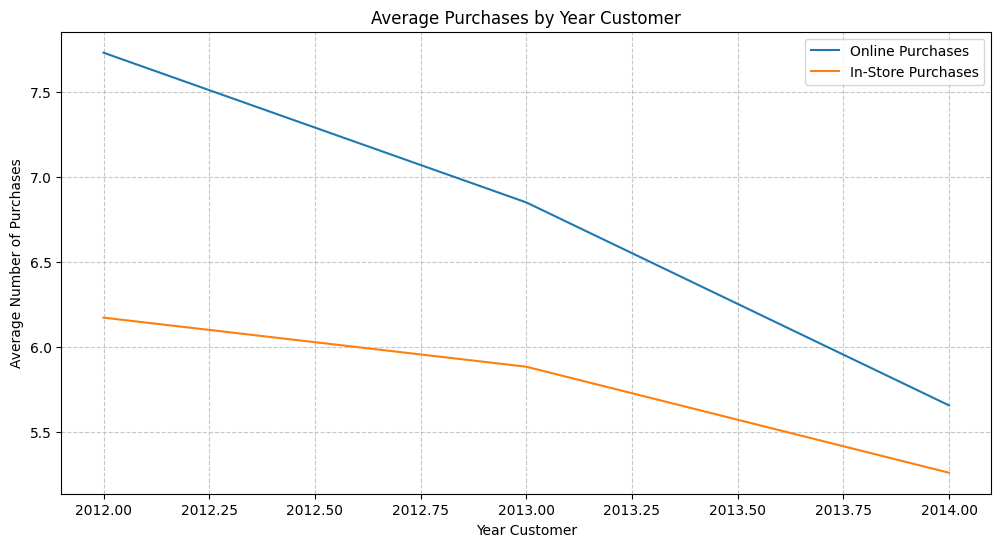

In [612]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Year_Birth and calculate the mean for 'Online Purchases' and 'NumStorePurchases'
purchases_by_year = df.groupby('Year_Customer')[['Online Purchases', 'NumStorePurchases']].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=purchases_by_year, x='Year_Customer', y='Online Purchases', label='Online Purchases')
sns.lineplot(data=purchases_by_year, x='Year_Customer', y='NumStorePurchases', label='In-Store Purchases')

plt.title('Average Purchases by Year Customer')
plt.xlabel('Year Customer')
plt.ylabel('Average Number of Purchases')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()